# Combining 1a and 1b through visualization

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
power_df = pd.read_csv("/content/drive/MyDrive/Wharton Data Science Competition 2026/power_ranking.csv")
power_df = power_df.drop(columns="Unnamed: 0")
power_df

,team,GP,z_win_pct,z_avg_goal_diff,z_avg_shot_share,z_avg_xg_share,z_avg_shot_diff_per60,z_avg_xg_diff_per60,z_avg_pim_diff_per60,z_xg_per_shot,power_score,z_power_score
0,pakistan,82,1.154701,1.241826,2.310820,1.418222,2.397636,1.537960,0.981909,0.734542,1.580285,1.908516
1,thailand,82,1.299038,1.120079,1.023348,2.019259,1.053884,2.099808,0.138939,2.060820,1.470770,1.776255
2,peru,82,1.587713,1.899264,1.724832,1.058860,1.555498,0.891977,-0.090932,-0.631834,1.331924,1.608570
3,brazil,82,2.453739,2.118410,-0.364125,1.473965,-0.387173,1.463947,0.380831,2.114816,1.281699,1.547912
4,netherlands,82,1.876388,1.680118,0.503674,1.207369,0.566733,1.188234,-1.191538,0.503015,1.161914,1.403248
5,uk,82,-0.288675,0.803535,0.827627,1.031357,0.796550,1.025781,-1.045273,1.514868,0.703772,0.849948
6,china,82,0.866025,1.120079,-0.230778,0.974765,-0.097294,1.047159,-0.420018,1.118521,0.700669,0.846201
7,panama,82,0.721688,1.022681,0.299173,0.420162,0.299373,0.455041,-0.621755,0.641871,0.550210,0.664491
8,mexico,82,-0.433013,-0.413942,1.099176,1.156254,1.106109,1.139783,0.563107,0.078440,0.542280,0.654914
9,india,82,1.154701,0.681787,0.857095,0.172238,0.831145,0.055285,-0.988772,-1.306158,0.492029,0.594225


In [ ]:
disp = pd.read_csv("/content/drive/MyDrive/Wharton Data Science Competition 2026/disp_ratio_team.csv")
disp = disp.drop(columns="Unnamed: 0")
disp

,team,first_off,second_off,disparity_ratio
0,usa,1.205849,0.883555,1.364769
1,guatemala,1.245976,0.917284,1.358333
2,saudi_arabia,0.993255,0.734887,1.351576
3,uae,0.885498,0.656895,1.348006
4,france,1.131184,0.843113,1.341675
5,iceland,1.144418,0.869322,1.316450
6,singapore,1.164558,0.930851,1.251069
7,new_zealand,1.079437,0.875572,1.232836
8,peru,1.057523,0.878751,1.203438
9,panama,1.125063,0.938738,1.198484


In [ ]:
plot_df = (power_df[["team", "z_power_score"]].merge(disp[["team", "disparity_ratio"]], on="team", how="inner") )
plot_df["disparity_log"] = (plot_df["disparity_ratio"]).apply(lambda x: __import__("math").log(x))
plot_df

,team,z_power_score,disparity_ratio,disparity_log
0,pakistan,1.908516,1.037573,0.036885
1,thailand,1.776255,0.964058,-0.036604
2,peru,1.608570,1.203438,0.185183
3,brazil,1.547912,0.982761,-0.017389
4,netherlands,1.403248,1.104451,0.099348
5,uk,0.849948,1.169136,0.156265
6,china,0.846201,1.049740,0.048543
7,panama,0.664491,1.198484,0.181058
8,mexico,0.654914,1.065109,0.063077
9,india,0.594225,1.165429,0.153090


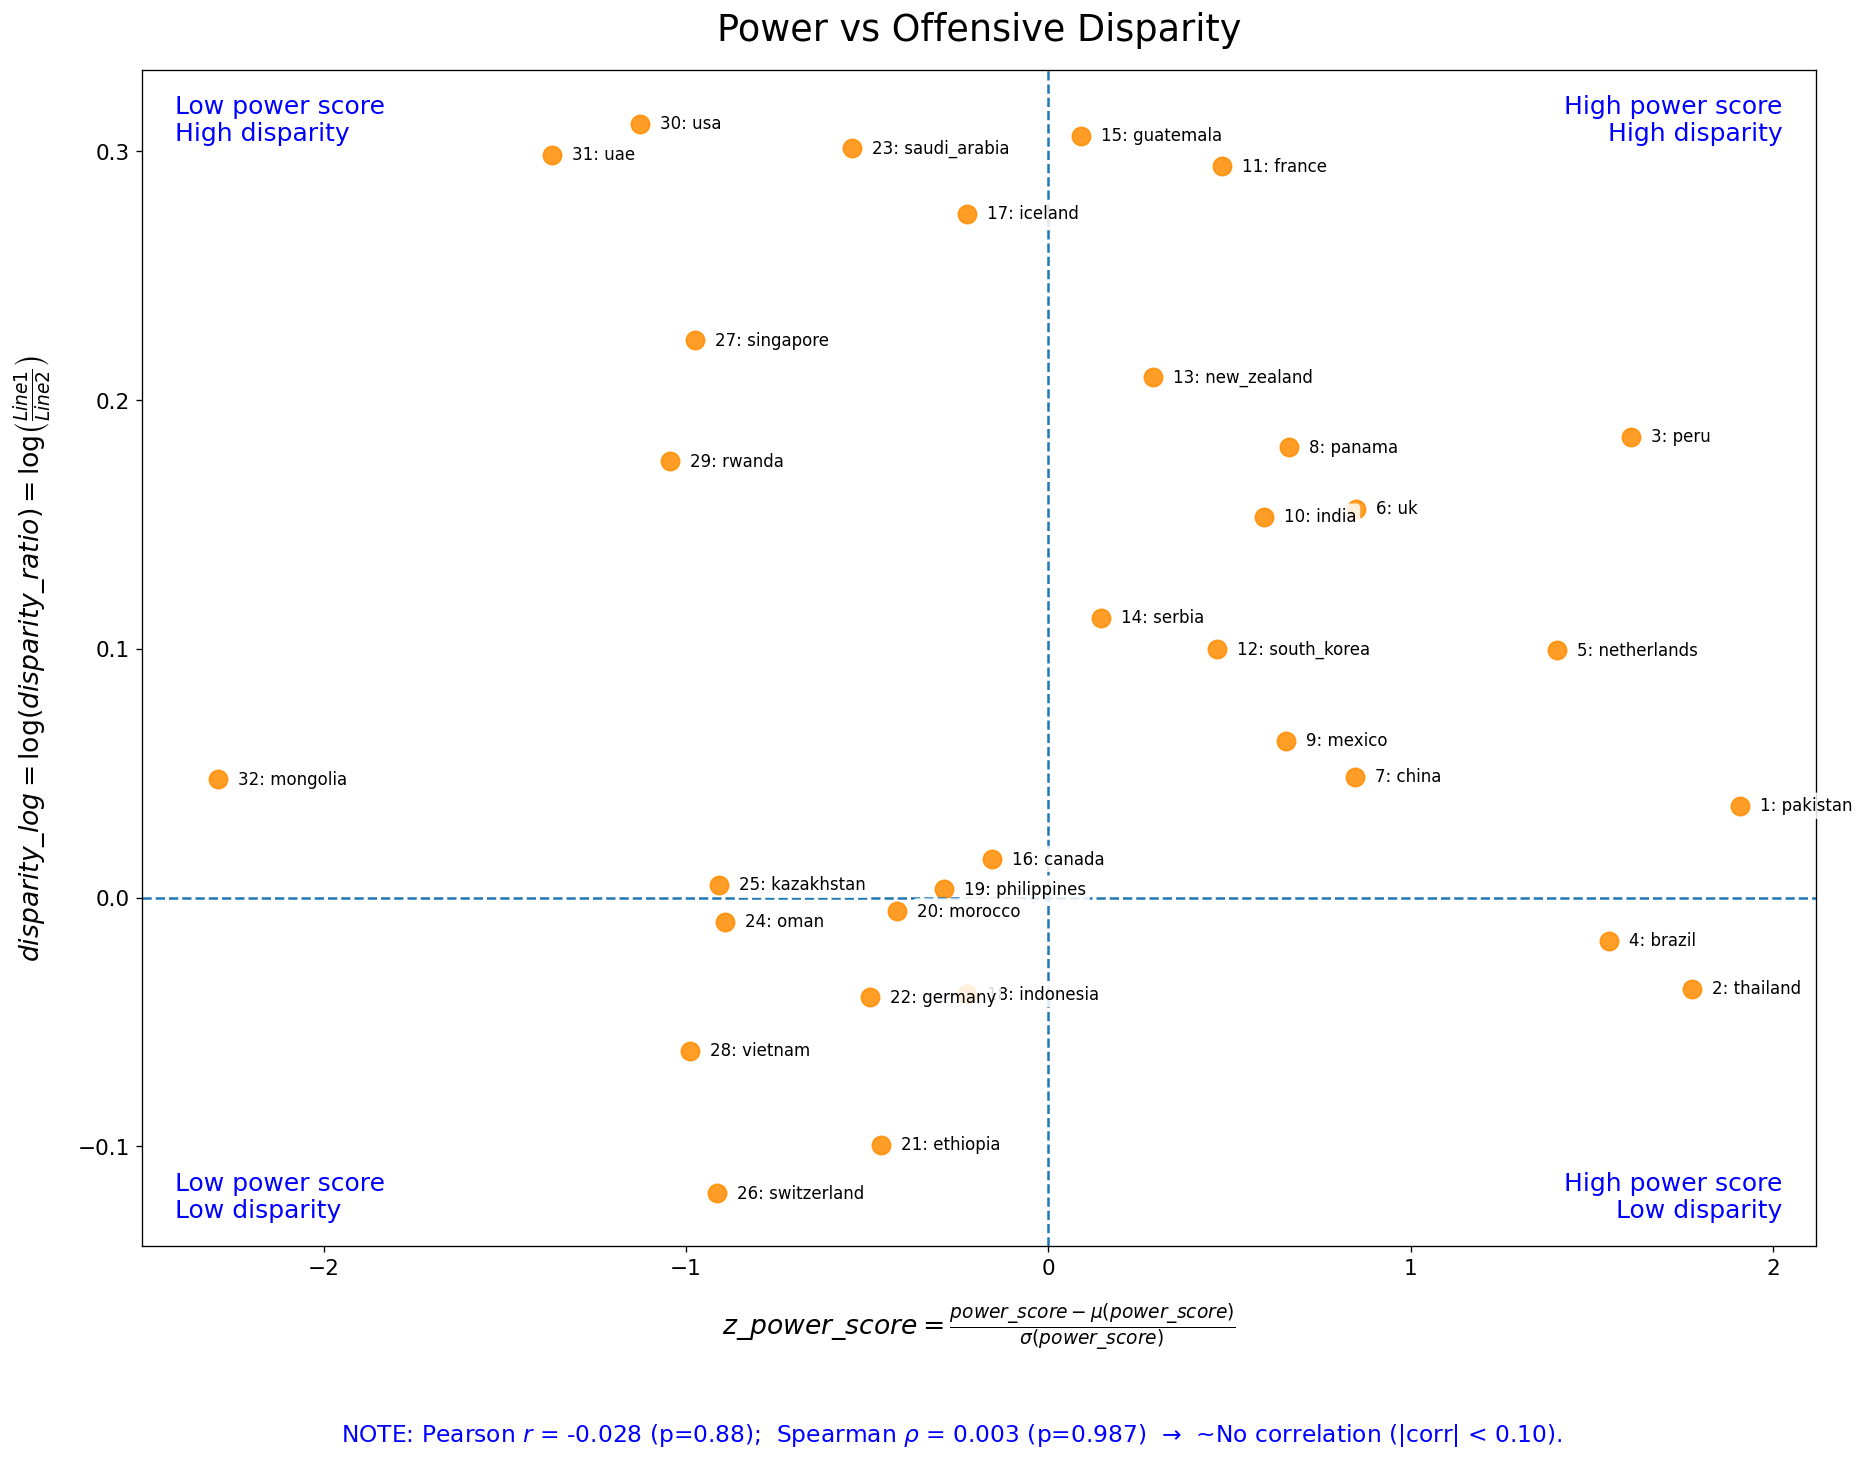

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr, spearmanr

# rank by z_power_score (1 = highest power)
rank_df = plot_df.sort_values("z_power_score", ascending=False).reset_index(drop=True)
rank_df["place"] = rank_df.index + 1

# correlations (overall)
x = rank_df["z_power_score"].values
y = rank_df["disparity_log"].values
r, p_r = pearsonr(x, y)
rho, p_rho = spearmanr(x, y)

fig, ax = plt.subplots(figsize=(18, 14), dpi=120)

# bigger, darker orange dots
ax.scatter(rank_df["z_power_score"], rank_df["disparity_log"],
           color="darkorange", alpha=0.85, s=120, zorder=1)

ax.axvline(0, linestyle="--")
ax.axhline(0, linestyle="--")

# ---- spacing controls (KEY CHANGES) ----
# bottom reserves space for note; top creates breathing room above title
fig.subplots_adjust(bottom=0.20, top=0.90)

# Bigger title + axis label fonts (with formulas)
title_fs = 22
ax.set_title("Power vs Offensive Disparity", fontsize=title_fs, pad=18)  # pad adds space from plot
ax.set_xlabel(r"$z\_power\_score=\frac{power\_score-\mu(power\_score)}{\sigma(power\_score)}$", fontsize=16, labelpad=14)
ax.set_ylabel(r"$disparity\_log=\log(disparity\_ratio)=\log\!\left(\frac{Line1}{Line2}\right)$", fontsize=16, labelpad=14)
ax.tick_params(axis="both", labelsize=13)

# label EVERY dot as "place: team" with dx=12, dy=0
dx, dy = 12, 0
for _, row in rank_df.iterrows():
    p = int(row["place"])
    ax.annotate(
        f"{p}: {row['team']}",
        xy=(row["z_power_score"], row["disparity_log"]),
        xytext=(dx, dy),
        textcoords="offset points",
        ha="left",
        va="center",
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.85, edgecolor="none"),
        zorder=3
    )

# quadrant labels (blue + slightly bigger)
q_bbox = dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85, edgecolor="none")
q_color = "blue"
q_fs = 15

ax.text(0.98, 0.98, "High power score\nHigh disparity",
        transform=ax.transAxes, ha="right", va="top",
        fontsize=q_fs, color=q_color, bbox=q_bbox, zorder=4)

ax.text(0.02, 0.98, "Low power score\nHigh disparity",
        transform=ax.transAxes, ha="left", va="top",
        fontsize=q_fs, color=q_color, bbox=q_bbox, zorder=4)

ax.text(0.02, 0.02, "Low power score\nLow disparity",
        transform=ax.transAxes, ha="left", va="bottom",
        fontsize=q_fs, color=q_color, bbox=q_bbox, zorder=4)

ax.text(0.98, 0.02, "High power score\nLow disparity",
        transform=ax.transAxes, ha="right", va="bottom",
        fontsize=q_fs, color=q_color, bbox=q_bbox, zorder=4)

# ---- note at the bottom (same blue, SMALLER) ----
no_corr_flag = (abs(r) < 0.10) and (abs(rho) < 0.10)
note = (
    rf"NOTE: Pearson $r$ = {r:.3f} (p={p_r:.3g});  Spearman $\rho$ = {rho:.3f} (p={p_rho:.3g})"
    + ("  →  ~No correlation (|corr| < 0.10)." if no_corr_flag else "  →  Some association present.")
)

note_fs = 14
# Put note in the reserved footer band, not on the edge
fig.text(0.5, 0.08, note, ha="center", va="bottom",
         fontsize=note_fs, color=q_color)

plt.show()

### Pearson vs. Spearman Correlation (what these numbers mean)

In this analysis we compare:

- **x = `z_power_score`**: a standardized team “power” rating (already on a z-scale).
- **y = `disparity_log`**: the **log** of `disparity_ratio` (centered at 0 because `log(1)=0`).

We compute **two** correlations because they answer different questions:

---

#### 1) Pearson correlation (`pearsonr`)
**Pearson r** measures **linear association** (a straight-line relationship).

- **r = +1**: perfect increasing line (as power increases, disparity increases proportionally)
- **r = −1**: perfect decreasing line
- **r ≈ 0**: no linear trend

Pearson is sensitive to the actual numeric spacing of points and can miss relationships that are curved/nonlinear.

---

#### 2) Spearman correlation (`spearmanr`)
**Spearman rho (ρ)** measures **rank (monotonic) association**.

Conceptually it works like this:
1. Convert `x` values into ranks (1 = lowest, N = highest).
2. Convert `y` values into ranks.
3. Compute a Pearson correlation **on the ranks**.

So Spearman answers:  
> “Do teams that rank higher in power tend to also rank higher (or lower) in disparity, even if the relationship is not a straight line?”

- **ρ = +1**: perfect monotonic increasing ordering (rank order matches)
- **ρ = −1**: perfect monotonic decreasing ordering (reverse rank order)
- **ρ ≈ 0**: no consistent rank relationship

Spearman is more robust to outliers and is useful when the relationship might be nonlinear but still consistently increasing/decreasing.

---

#### 3) What the p-values mean
Both functions return a **p-value** testing the null hypothesis:

> **H₀:** there is **no association** (correlation = 0)

- Small p-value (commonly < 0.05) suggests evidence of an association.
- Large p-value suggests the observed correlation is consistent with **no relationship**.

---

#### 4) Interpreting our results
If both **Pearson r** and **Spearman ρ** are near 0 with large p-values, then:

- There is **no meaningful linear relationship** (Pearson),
- and **no meaningful monotonic/rank relationship** (Spearman),

between `z_power_score` and `disparity_log` in this dataset.

This suggests **overall team strength (power)** and **top-heaviness/depth (disparity)** are largely **independent dimensions**.

In [ ]:
from scipy.stats import pearsonr, spearmanr

x = plot_df["z_power_score"]
y = plot_df["disparity_log"]   # or log_disparity

r, p_r = pearsonr(x, y)
rho, p_rho = spearmanr(x, y)

print(f"Pearson r = {r:.3f}, p = {p_r:.3g}")
print(f"Spearman rho = {rho:.3f}, p = {p_rho:.3g}")

Pearson r = -0.028, p = 0.88
Spearman rho = 0.003, p = 0.987


Spearman (p) and Perason (r) show basically no correlation.

In [ ]:
# Trying alternative PCA power ranking to see if there is a correlation there
power_pca = pd.read_csv("/content/drive/MyDrive/Wharton Data Science Competition 2026/power_ranking_PCA.csv")
power_pca = power_pca.drop(columns="Unnamed: 0")
power_pca

,team,GP,z_win_pct,z_avg_goal_diff,z_avg_shot_share,z_avg_xg_share,z_avg_shot_diff_per60,z_avg_xg_diff_per60,z_avg_pim_diff_per60,z_xg_per_shot,power_score_pca,z_power_score
0,pakistan,82,1.154701,1.241826,2.310820,1.418222,2.397636,1.537960,0.981909,0.734542,3.817500,1.857908
1,thailand,82,1.299038,1.120079,1.023348,2.019259,1.053884,2.099808,0.138939,2.060820,3.779966,1.839641
2,peru,82,1.587713,1.899264,1.724832,1.058860,1.555498,0.891977,-0.090932,-0.631834,2.736451,1.331781
3,uk,82,-0.288675,0.803535,0.827627,1.031357,0.796550,1.025781,-1.045273,1.514868,2.497326,1.215403
4,netherlands,82,1.876388,1.680118,0.503674,1.207369,0.566733,1.188234,-1.191538,0.503015,2.467792,1.201029
5,brazil,82,2.453739,2.118410,-0.364125,1.473965,-0.387173,1.463947,0.380831,2.114816,2.449450,1.192103
6,france,82,-0.577350,-0.584389,1.133646,0.891302,1.072168,0.963382,-1.777858,1.093009,2.090468,1.017393
7,mexico,82,-0.433013,-0.413942,1.099176,1.156254,1.106109,1.139783,0.563107,0.078440,1.759402,0.856269
8,china,82,0.866025,1.120079,-0.230778,0.974765,-0.097294,1.047159,-0.420018,1.118521,1.620900,0.788863
9,panama,82,0.721688,1.022681,0.299173,0.420162,0.299373,0.455041,-0.621755,0.641871,1.295721,0.630604


In [ ]:
# same steps as above
plot_df_pca = (
    power_pca[["team", "z_power_score"]]
    .merge(disp[["team", "disparity_ratio"]], on="team", how="inner")
)
plot_df_pca["disparity_log"] = (plot_df_pca["disparity_ratio"]).apply(lambda x: __import__("math").log(x))
plot_df_pca

,team,z_power_score,disparity_ratio,disparity_log
0,pakistan,1.857908,1.037573,0.036885
1,thailand,1.839641,0.964058,-0.036604
2,peru,1.331781,1.203438,0.185183
3,uk,1.215403,1.169136,0.156265
4,netherlands,1.201029,1.104451,0.099348
5,brazil,1.192103,0.982761,-0.017389
6,france,1.017393,1.341675,0.293919
7,mexico,0.856269,1.065109,0.063077
8,china,0.788863,1.049740,0.048543
9,panama,0.630604,1.198484,0.181058


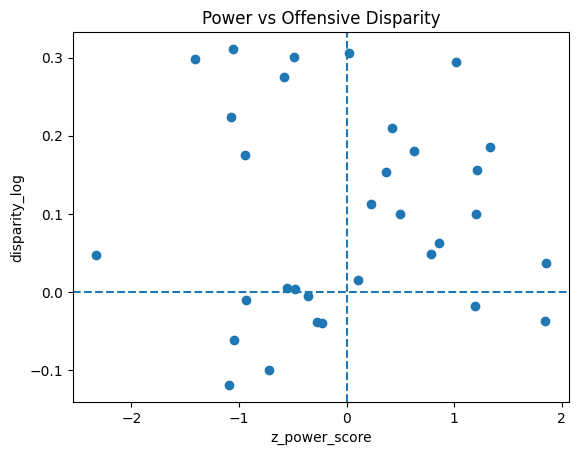

In [ ]:
# scatter
plt.figure()
plt.scatter(plot_df_pca["z_power_score"], plot_df_pca["disparity_log"])

# reference lines
plt.axvline(0, linestyle="--")
plt.axhline(0, linestyle="--")

plt.xlabel("z_power_score")
plt.ylabel("disparity_log")
plt.title("Power vs Offensive Disparity")
plt.show()

In [ ]:
from scipy.stats import pearsonr, spearmanr

x = plot_df_pca["z_power_score"]
y = plot_df_pca["disparity_log"]   # or log_disparity

r, p_r = pearsonr(x, y)
rho, p_rho = spearmanr(x, y)

print(f"Pearson r = {r:.3f}, p = {p_r:.3g}")
print(f"Spearman rho = {rho:.3f}, p = {p_rho:.3g}")

Pearson r = -0.003, p = 0.988
Spearman rho = 0.024, p = 0.897


In [ ]:
# seeing optential overlap in position
plot_df_pca == plot_df

,team,z_power_score,disparity_ratio,disparity_log
0,True,False,True,True
1,True,False,True,True
2,True,False,True,True
3,False,False,False,False
4,True,False,True,True
5,False,False,False,False
6,False,False,False,False
7,False,False,False,False
8,False,False,False,False
9,False,False,False,False


## Overall there is still not much correlation